# **1. Project Overview**

## 1.1 Business Objective

The objective of this project is building machine learning models that can accurately predict housing prices based on property characteristics.
Accurate housing price predictions can support real estate agencies, buyers, sellers, and property investors in making informed decisions.
The model help find key factors influencing house prices and improve pricing consistency in the housing market.

## 1.2 Experiment Objective

The objective of this experiment is to develop and evaluate an XGBoost Regression model for predicting housing prices. XGBoost is an advanced boosting algorithm that can capture complex non-linear relationships while controlling overfitting through regularisation. The model will be compared against previous models (Random Forest, ElasticNet, and Linear Regression) to identify the best-performing approach for housing price prediction.

## 1.3 Model Hypothesis

The XGBoost model is expected to outperform the previous models by capturing complex interactions and non-linear relationships among housing characteristics. Due to its boosting mechanism and built-in regularisation, XGBoost is expected to achieve lower prediction errors and stronger generalisation performance than previous models.

# **2. Load Dataset**

In [1]:
import pandas as pd
import numpy as np

In [2]:
X_train = pd.read_csv('../data/X_train_processed.csv')
X_val = pd.read_csv('../data/X_val_processed.csv')
X_test = pd.read_csv('../data/X_test_processed.csv')

y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_val = pd.read_csv('../data/y_val.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

# **3. Model Development**

## 3.1 Import Algorithm

In [3]:
# Import Gradient Boosting Regressor from sklearn
from sklearn.ensemble import GradientBoostingRegressor

## 3.2 Set Hyperparameters

In [4]:
# Define the range of hyperparameters
n_estimators_values = [100, 300]
max_depth_values = [3, 5]
learning_rate_values = [0.01, 0.1]

## 3.3 Train Model

In [5]:
# Import RMSE, RAE, R2 score from sklearn
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score

In [6]:
# Fit Model
results = []

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for learning_rate in learning_rate_values:
            gb = GradientBoostingRegressor(
            n_estimators = n_estimators,
            max_depth = max_depth,
            learning_rate = learning_rate,
            random_state = 42)
        
            gb.fit(X_train, y_train)
        
            y_val_pred = gb.predict(X_val)
        
            results.append({
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'learning_rate': learning_rate,
            'RMSE': rmse(y_val, y_val_pred),
            'MAE': mae(y_val, y_val_pred),
            'R2_Score': r2_score(y_val, y_val_pred)
            })
        
results_df = pd.DataFrame(results)
results_df.sort_values(by = 'RMSE') 

,n_estimators,max_depth,learning_rate,RMSE,MAE,R2_Score
3,100,5,0.10,0.113124,0.081803,0.928835
5,300,3,0.10,0.113463,0.082220,0.928409
7,300,5,0.10,0.113507,0.081925,0.928353
1,100,3,0.10,0.116063,0.085846,0.925090
6,300,5,0.01,0.123310,0.088064,0.915443
4,300,3,0.01,0.134798,0.096769,0.898955
2,100,5,0.01,0.208436,0.152303,0.758399
0,100,3,0.01,0.228417,0.166002,0.709860


In [8]:
# Select the Best Model
best_gb = GradientBoostingRegressor(
    n_estimators=100, 
    max_depth = 5,
    learning_rate = 0.10,
    random_state=42)

best_gb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

The model with n_estimators=100, max_depth=5, and learning_rate=0.10 achieved the lowest validation RMSE. Although several hyperparameter combinations produced similar results, this configuration was selected as the final model because it achieved the best validation performance while maintaining lower model complexity than alternatives with larger numbers of trees.

## 3.4 Generate Predictions

In [9]:
y_train_pred = best_gb.predict(X_train)
y_val_pred = best_gb.predict(X_val)
y_test_pred = best_gb.predict(X_test)

# **4. Model Evaluation**

## 4.1 Technical Performance

In [10]:
# Check the Gradient Boosting Regressor performance
model_results = pd.DataFrame({
    'Dataset': ['Train', 'Val', 'Test'],
    'RMSE': [
        rmse(y_train, y_train_pred),
        rmse(y_val, y_val_pred),
        rmse(y_test, y_test_pred)
    ],
    'MAE': [
        mae(y_train, y_train_pred),
        mae(y_val, y_val_pred),
        mae(y_test, y_test_pred)
    ],
    'R2_Score': [
        r2_score(y_train, y_train_pred),
        r2_score(y_val, y_val_pred),
        r2_score(y_test, y_test_pred)
    ]
})

model_results

,Dataset,RMSE,MAE,R2_Score
0,Train,0.086856,0.064528,0.953116
1,Val,0.113124,0.081803,0.928835
2,Test,0.147154,0.100152,0.886141


## 4.2 Prediction Visualisation

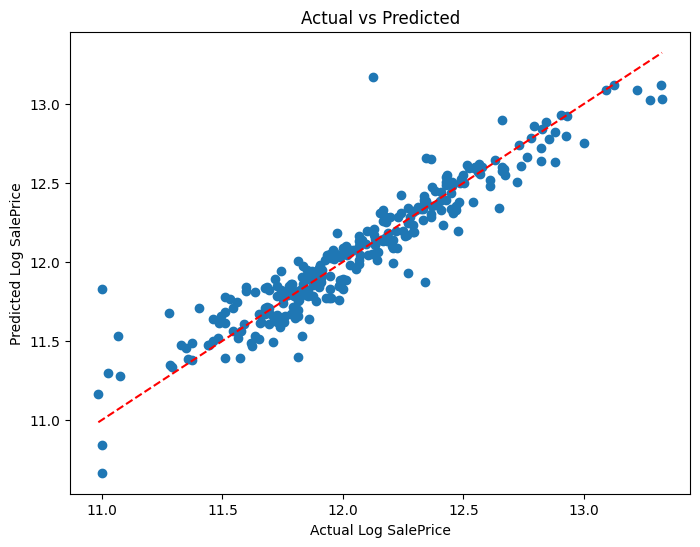

In [11]:
# Scatterplot of Actual Log SalePrice vs Predicted Log SalePrice
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (8,6))

plt.scatter(y_test, y_test_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Log SalePrice')
plt.ylabel('Predicted Log SalePrice')
plt.title('Actual vs Predicted')

plt.show()

The scatter plot demonstrates a strong agreement between the observed and predicted housing prices. The Gradient Boosting model successfully captures the relationship between property characteristics and housing prices as most predictions are located close to the ideal prediction line. Compared with previous models, the predictions appear more tightly clustered around the ideal line. Gradient Boosting improved predictive performance and generalisation ability.

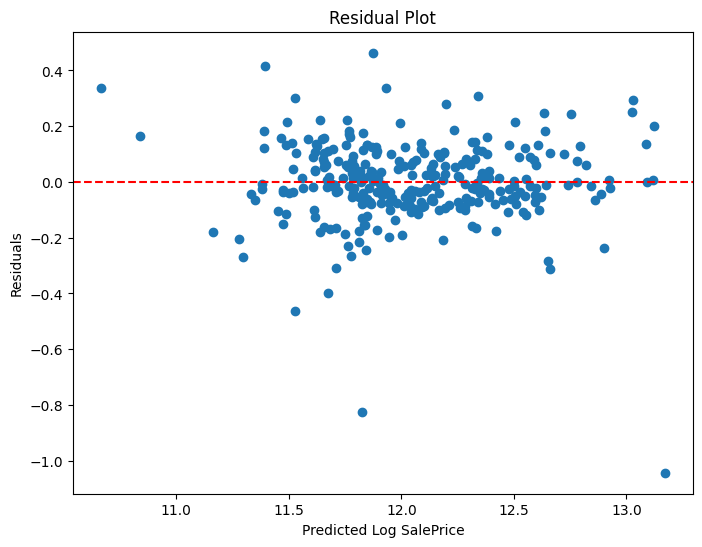

In [12]:
# Residual plot
residuals = y_test - y_test_pred

plt.figure(figsize=(8,6))

plt.scatter(y_test_pred, residuals)

plt.axhline(color = 'red', ls = '--')

plt.xlabel('Predicted Log SalePrice')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

The residuals are generally centred around zero and do not exhibit a strong systematic pattern. This suggests that the Gradient Boosting model captures most of the underlying structure within the data and produces relatively unbiased predictions. Although several larger residuals remain, the overall distribution indicates strong predictive performance and good generalisation to unseen observations.

## 4.3 Model Interpretation

In [13]:
# Extract Top 10 Important Features

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_gb.feature_importances_
})

importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
0,num__Overall Qual,0.543974
1,num__Gr Liv Area,0.115143
11,ord__Kitchen Qual,0.061116
6,num__Year Built,0.047144
4,num__Total Bsmt SF,0.045122
5,num__1st Flr SF,0.043752
2,num__Garage Cars,0.041665
3,num__Garage Area,0.038815
10,ord__Exter Qual,0.018250
46,nom__MS Zoning_RM,0.007947


The Gradient Boosting model identified `Overall Qual` as the most influential predictor of housing prices. `Gr Liv Area` was the second most important variable, followed by `Kitchen Qual`, `Year Built`, and `Total Bsmt SF`. These findings are consistent with the results from the EDA and previous modelling experiments, indicating again that property quality, size, and age are key determinants of housing value.

## 4.4 Business Interpretation

The Gradient Boosting model suggests that overall property quality is the strongest driver of housing prices, followed by living area, kitchen quality, construction year, and basement size. These findings indicate that buyers place substantial value on both the quality and usability of a property. Such insights may assist real estate agencies, property investors, and homeowners in identifying the characteristics most strongly associated with higher market values.

# **5. Experiment Outcomes**

## 5.1 Key Findings

Gradient Boosting achieved the **lowest test RMSE** and **highest test R2 score**. It showed the strongest predictive performance among all evaluated models. Compared with Random Forest, the model demonstrated better generalisation performance despite slightly lower training accuracy.

## 5.2 Hypothesis Evaluation

**The hypothesis was supported.** The Gradient Boosting model outperformed the previous models and achieved the best overall predictive performance. The boosting approach successfully captured complex relationships within the data while maintaining strong generalisation performance on unseen observations.

## 5.3 Limitations

- Although Gradient Boosting achieved the strongest predictive performance, the model remains dependent on the selected feature set and may not fully utilise information contained in excluded variables.
- Some prediction errors remain for extreme housing prices. Certain market factors are not fully captured by the current model. Further feature engineering and hyperparameter optimisation may lead to additional performance improvements.

## 5.4 Summary

Among all evaluated models, **Gradient Boosting** achieved the best balance between predictive accuracy and generalisation performance. Therefore, it was selected as the final model for this project and will be used for further evaluation, model comparison, and deployment preparation.

## 5.4 Save Final Model

In [15]:
import joblib

joblib.dump(
    best_gb,
    '../outputs/gradient_boosting_model.pkl'
)

['../outputs/gradient_boosting_model.pkl']